##1. Data Loading & Initial Inspection
In this phase, we load the dataset and inspect its structure. We identify column types (numeric vs. categorical) and look for data quality issues, such as prices stored as text strings with currency symbols.

In [6]:
!pip install numpy

Looking in links: /usr/share/pip-wheels


In [12]:
!pip install seaborn
!pip install scikit-learn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

Looking in links: /usr/share/pip-wheels
Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 64.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 71.9 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] 3/4 [scikit-learn]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mne 1.11.0 requires lazy-loader>=0.3, which is not installed.
mne 1.11.0 requires tqdm, which is not installed.


In [3]:
!pip install pandas

import pandas as pd

df = pd.read_csv("Airbnb_Open_Data.csv")
print(df.head())

Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 83.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]━━━━━ 2/3 [pandas]
        id                                              NAME      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host name neighbourhood group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   
3            unconfirmed     Garry            Brooklyn  Cl

/tmp/ipykernel_196/1574537746.py:5: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Airbnb_Open_Data.csv")


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [5]:
print(df.describe())

                 id       host id            lat           long  \
count  1.025990e+05  1.025990e+05  102591.000000  102591.000000   
mean   2.914623e+07  4.925411e+10      40.728094     -73.949644   
std    1.625751e+07  2.853900e+10       0.055857       0.049521   
min    1.001254e+06  1.236005e+08      40.499790     -74.249840   
25%    1.508581e+07  2.458333e+10      40.688740     -73.982580   
50%    2.913660e+07  4.911774e+10      40.722290     -73.954440   
75%    4.320120e+07  7.399650e+10      40.762760     -73.932350   
max    5.736742e+07  9.876313e+10      40.916970     -73.705220   

       Construction year  minimum nights  number of reviews  \
count      102385.000000   102190.000000      102416.000000   
mean         2012.487464        8.135845          27.483743   
std             5.765556       30.553781          49.508954   
min          2003.000000    -1223.000000           0.000000   
25%          2007.000000        2.000000           1.000000   
50%          2012.

2. Data Cleaning
Numeric Conversion: Converting price and service fee from strings to floats.
Imputation: Filling missing values using the median to avoid the influence of outliers.
Standardization: Fixing typos in neighborhood names.

In [7]:
# a) remove irrelevant columns
cols_to_drop = ['id', 'host id', 'license', 'house_rules', 'NAME', 'host name', 'last review', 'country code']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# b) remove $ and transform from string to float
for col in ['price', 'service fee']:
    df[col] = df[col].replace('[\$,]', '', regex=True).astype(float)

# c) missing values
# use the median to not influence the result
df['reviews per month'] = df['reviews per month'].fillna(0)
df['review rate number'] = df['review rate number'].fillna(df['review rate number'].median())
df['minimum nights'] = df['minimum nights'].fillna(df['minimum nights'].median())
df['Construction year'] = df['Construction year'].fillna(df['Construction year'].median())
df['price'] = df['price'].fillna(df['price'].median())
df['service fee'] = df['service fee'].fillna(df['service fee'].median())

# d) remove the negative nights and availability greater than 365
df = df[df['minimum nights'] >= 0]
df = df[(df['availability 365'] >= 0) & (df['availability 365'] <= 365)]
df = df.dropna(subset=['lat', 'long']) # Eliminăm rândurile fără coordonate

# e) fix the duplicates
df['neighbourhood group'] = df['neighbourhood group'].replace({'manhatan': 'Manhattan', 'brookln': 'Brooklyn'})

# e) Transform unconfirmed/verified in 0/1
df['host_identity_verified'] = df['host_identity_verified'].map({'unconfirmed': 0, 'verified': 1})
df['host_identity_verified'] = df['host_identity_verified'].fillna(0)

# f) remove Outliers
df = df[df['minimum nights'] > 0]
df = df[df['availability 365'] <= 365]

In [21]:
df['neighbourhood group'] = df['neighbourhood group'].fillna(df['neighbourhood group'].mode()[0])
df['neighbourhood'] = df['neighbourhood'].fillna(df['neighbourhood'].mode()[0])
df['country'] = df['country'].fillna('United States') # Știm că datele sunt din NYC

df['instant_bookable'] = df['instant_bookable'].fillna(df['instant_bookable'].mode()[0])
df['cancellation_policy'] = df['cancellation_policy'].fillna(df['cancellation_policy'].mode()[0])

df['number of reviews'] = df['number of reviews'].fillna(0)
df['calculated host listings count'] = df['calculated host listings count'].fillna(1)

/tmp/ipykernel_196/4073438485.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['instant_bookable'] = df['instant_bookable'].fillna(df['instant_bookable'].mode()[0])


In [22]:
df.isna().sum()

host_identity_verified            0
neighbourhood group               0
neighbourhood                     0
lat                               0
long                              0
country                           0
instant_bookable                  0
cancellation_policy               0
room type                         0
Construction year                 0
price                             0
service fee                       0
minimum nights                    0
number of reviews                 0
reviews per month                 0
review rate number                0
calculated host listings count    0
availability 365                  0
dtype: int64

In [23]:
df['host_identity_verified'].value_counts(dropna=False)

host_identity_verified
0.0    49614
1.0    49303
Name: count, dtype: int64

In [24]:
len(df)

98917

In [28]:
df['instant_bookable'].unique()

array([False,  True])

##EDA
The histogram reveals a **Uniform Distribution** of prices across the NYC Airbnb market.


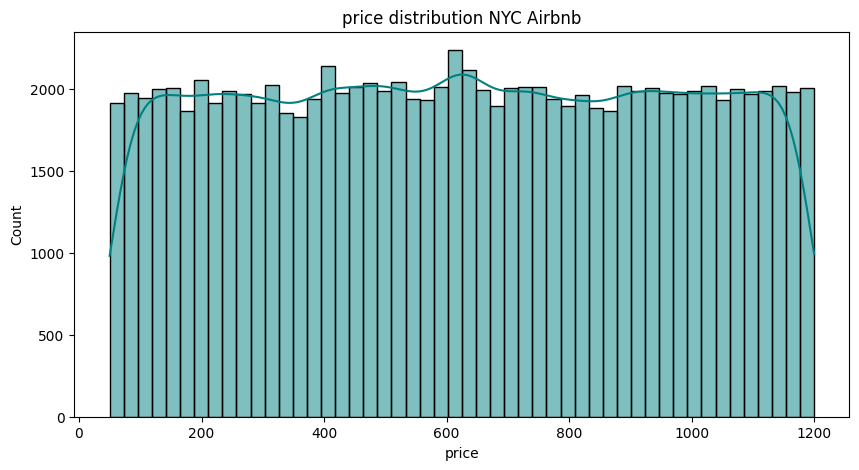

In [25]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True, color='teal')
plt.title('price distribution NYC Airbnb')
plt.show()

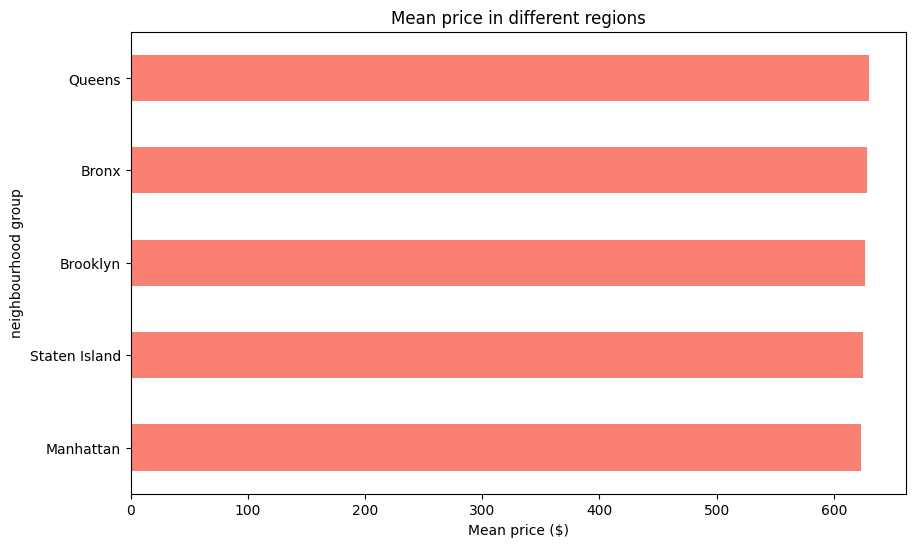

In [26]:
plt.figure(figsize=(10, 6))
df.groupby('neighbourhood group')['price'].mean().sort_values().plot(kind='barh', color='salmon')
plt.title('Mean price in different regions')
plt.xlabel('Mean price ($)')
plt.show()

**observation:** Surprizingly, the region is not as relevant as expected 

['Private room' 'Entire home/apt' 'Shared room' 'Hotel room']


/tmp/ipykernel_196/637224152.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='room type', y='price', data=df, palette='Set2')


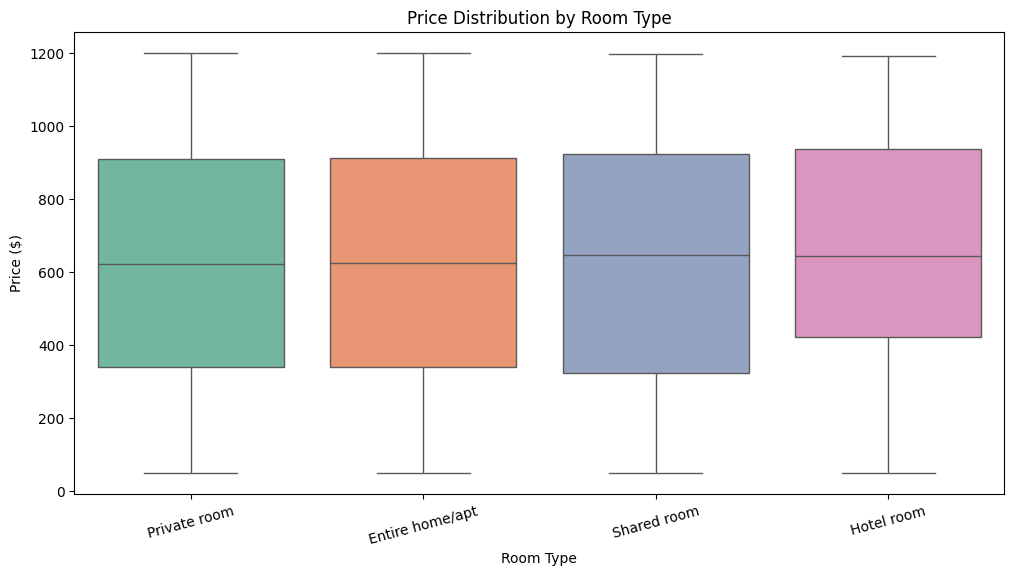

In [33]:
print(df['room type'].unique())

plt.figure(figsize=(12, 6))
sns.boxplot(x='room type', y='price', data=df, palette='Set2')

plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.xticks(rotation=15)
plt.show()

**observation:** we can observe that the price is similar

/tmp/ipykernel_196/3043002666.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='review rate number', y='price', data=df, palette='viridis')


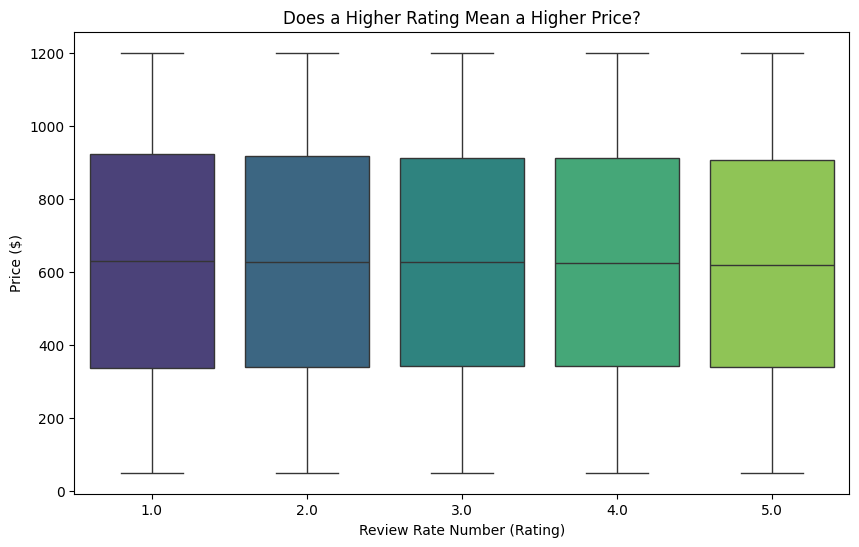

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='review rate number', y='price', data=df, palette='viridis')

plt.title('Does a Higher Rating Mean a Higher Price?')
plt.xlabel('Review Rate Number (Rating)')
plt.ylabel('Price ($)')
plt.show()

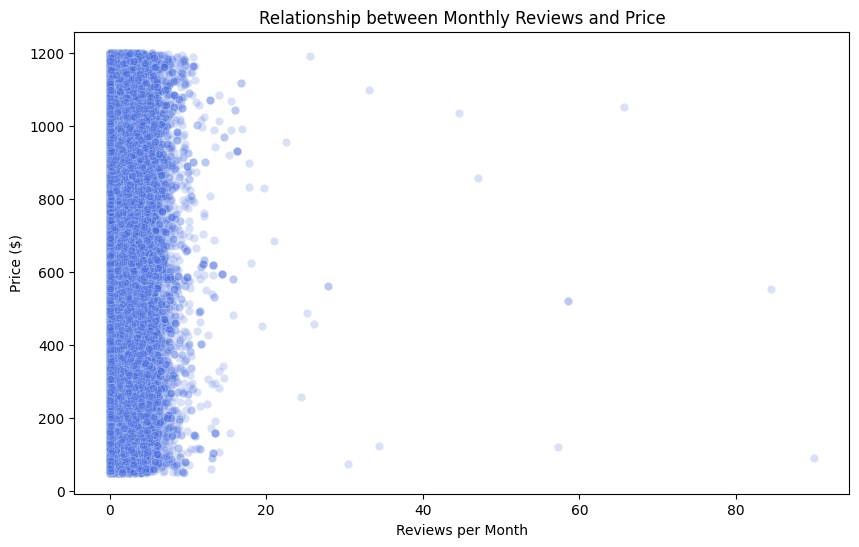

In [36]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x='reviews per month', y='price', data=df, alpha=0.2, color='royalblue')

plt.title('Relationship between Monthly Reviews and Price')
plt.xlabel('Reviews per Month')
plt.ylabel('Price ($)')
plt.show()

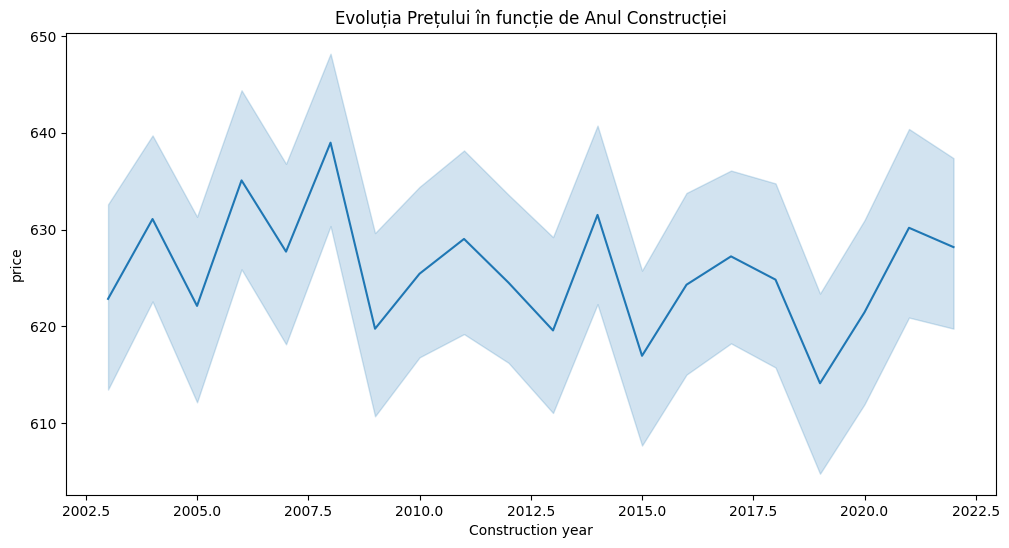

In [27]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Construction year', y='price', data=df)
plt.title('Evoluția Prețului în funcție de Anul Construcției')
plt.show()

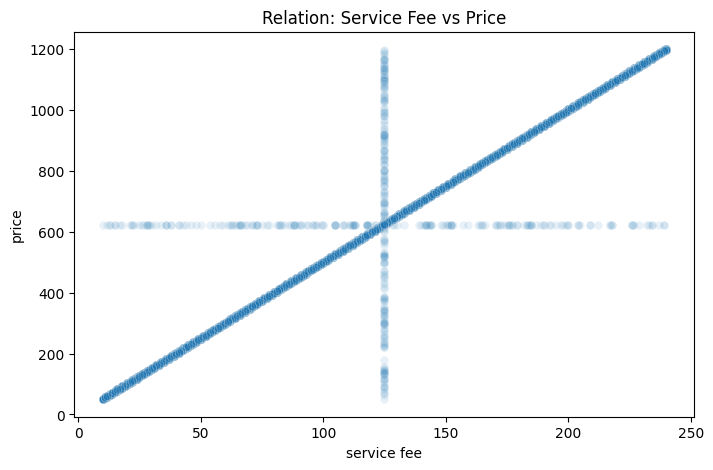

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='service fee', y='price', data=df, alpha=0.1)
plt.title('Relation: Service Fee vs Price')
plt.show()

In [29]:
df['instant_bookable'] = (
    df['instant_bookable']
        .fillna(df['instant_bookable'].mode()[0])
        .astype(str)
        .str.lower()
        .map({'true': 1, 'false': 0, 'yes': 1, 'no': 0})
)

In [30]:
df['price'].describe()

count    98917.000000
mean       625.749952
std        331.341382
min         50.000000
25%        341.000000
50%        624.000000
75%        913.000000
max       1200.000000
Name: price, dtype: float64

In [37]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

price                             1.000000
service fee                       0.997843
number of reviews                 0.006138
reviews per month                 0.005488
long                              0.001446
instant_bookable                  0.000461
calculated host listings count   -0.000213
availability 365                 -0.001725
host_identity_verified           -0.004331
Construction year                -0.004539
minimum nights                   -0.004778
lat                              -0.005991
review rate number               -0.006180
Name: price, dtype: float64

In [38]:
# 1. we create the target by splitting into 3 parts: cheap, medium and expensive
df['price_category'] = pd.qcut(df['price'], q=3, labels=['Cheap', 'Medium', 'Expensive'])

# 2. One-Hot Encoding (Borough și Room Type)
df_ml = pd.get_dummies(df, columns=['room type', 'neighbourhood group'], drop_first=True)

# 3. Select Features (X) and Target (y)
# remove price and service fee from X 
feature_cols = df_ml.select_dtypes(include=[np.number]).columns.tolist()
if 'price' in feature_cols: feature_cols.remove('price')
if 'service fee' in feature_cols: feature_cols.remove('service fee')

X = df_ml[feature_cols]
y = df_ml['price_category']

print(f"Use {len(feature_cols)} cols to predict the price category.")

Use 11 cols to predict the price category.


In [39]:
from sklearn.model_selection import train_test_split

# 80% for training 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"train on {X_train.shape[0]} rows and test on {X_test.shape[0]}.")

train on 79133 rows and test on 19784.


In [ ]:
I will use **Random Forest**:
1.  **Captures Non-Linearity:** As seen in our EDA, features like coordinates and construction year don't have a simple linear relationship with price. Random Forest excels at finding complex patterns.
2.  **Robustness:** It is less sensitive to outliers and "noise" in the Airbnb data.
3.  **Feature Importance:** It allows us to mathematically rank which factors (like location vs. building age) actually drive the price.
4.  **Ensemble Learning:** By combining 100 decision trees, it reduces the risk of overfitting compared to a single decision tree.

In [40]:
# 1. Initialize the Random Forest Classifier
# We use 100 trees (n_estimators) to balance accuracy and processing time
clf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model using the training data
clf_model.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred = clf_model.predict(X_test)

# 4. Print the performance metrics
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 0.6438536190861303

Classification Report:
               precision    recall  f1-score   support

       Cheap       0.64      0.65      0.65      6628
   Expensive       0.64      0.64      0.64      6600
      Medium       0.64      0.63      0.64      6556

    accuracy                           0.64     19784
   macro avg       0.64      0.64      0.64     19784
weighted avg       0.64      0.64      0.64     19784



/tmp/ipykernel_196/1133542831.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='magma')


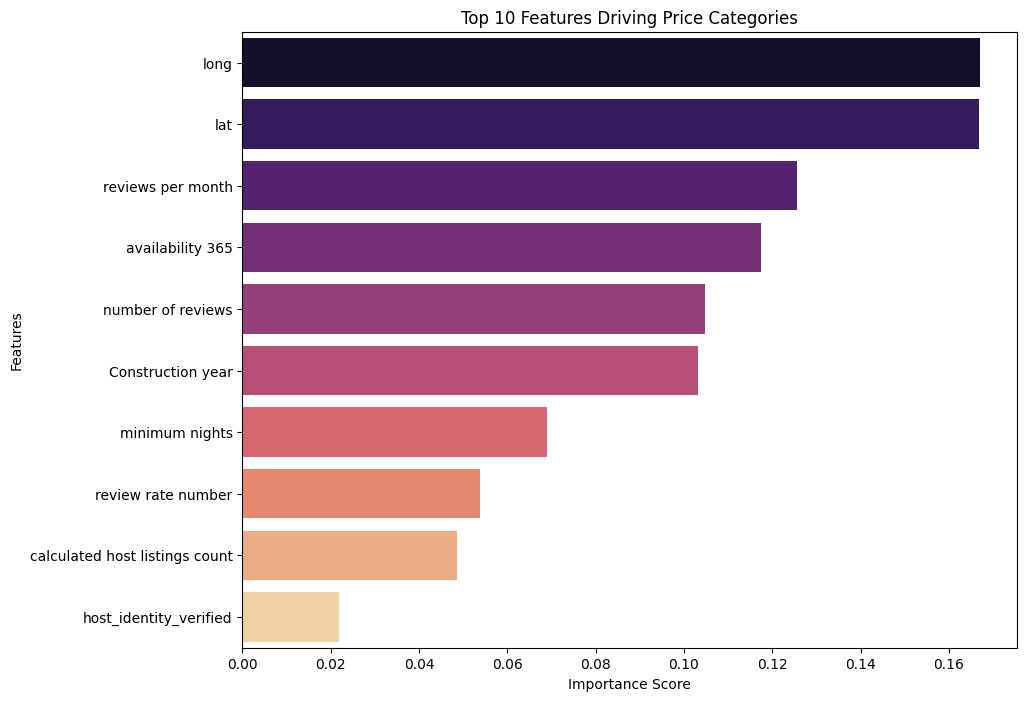

In [41]:
# Extract feature importances
importances = clf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting the top factors
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='magma')

plt.title('Top 10 Features Driving Price Categories')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()